In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metics
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Settings
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('All Libraries Loaded Succesfully')

All Libraries Loaded Succesfully


# 1. Load and Explore Dataset

In [2]:
df=pd.read_csv('Titanic-Dataset.csv')
print(f'Dataset Shape {df.shape}')
print('First few rows')
df.head()

Dataset Shape (891, 12)
First few rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Datset Information
print(f"\n Dataset Info {df.info()}")

# Target Distribution
print(f"Target Distribution")
print(df['Survived'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

 Dataset Info None
Target Distribution
Survived
0    549
1    342
Name: count, dtype: int64


In [4]:
# Check Missing Values 
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Check Duplicate values
print('Duplicate Values')
print(df.duplicated().sum())

Duplicate Values
0


In [6]:
# Descriptive Statistic
print("Discriptive Statistic")
df.describe()

Discriptive Statistic


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


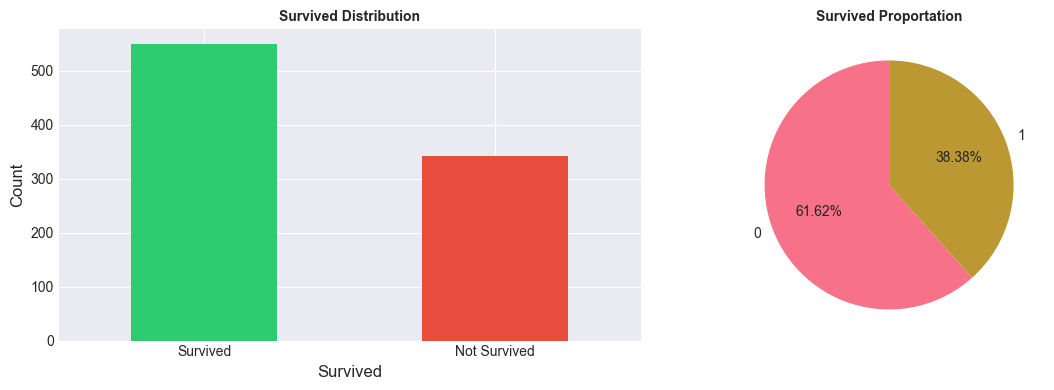

In [7]:
# Visualization Class Distribution
fig, axes = plt.subplots(1,2,figsize=(12,4))

# Count Plot
df['Survived'].value_counts().plot(kind='bar',ax=axes[0],color=['#2ecc71','#e74c3c'])
axes[0].set_title('Survived Distribution',fontsize=10,fontweight='bold')
axes[0].set_xlabel('Survived',fontsize=12)
axes[0].set_ylabel('Count',fontsize=12)
axes[0].set_xticklabels(['Survived','Not Survived'],rotation=0)

# Pie Chart
df['Survived'].value_counts().plot(kind='pie',ax=axes[1],autopct='%1.2f%%',color=['#2ecc71','#e74c3c'],startangle=90)
axes[1].set_title('Survived Proportation',fontsize=10,fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

# 2. Data Preprocessing

In [8]:
# Filling age with median
df['Age']= df['Age'].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))

In [9]:
# Drop useless columns
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [10]:
# Drop Null values
df.dropna(inplace=True)

In [11]:
# Label Encoding Sex and Embarked
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['Embarked'] = df['Embarked'].map({'C':0,'S':1})

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1.0
1,1,1,1,38.0,1,0,71.2833,0.0
2,1,3,1,26.0,0,0,7.9250,1.0
3,1,1,1,35.0,1,0,53.1000,1.0
4,0,3,0,35.0,0,0,8.0500,1.0


# Feature Engineering

In [13]:
# Total Family size 
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Check if passenger was travelling solo
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

# Family Type
df['FamilyType'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 6, 20], labels=[0, 1, 2, 3])
# Age Group
bins = [0,6, 12, 19, 60, 100]
labels = [0, 1,2,3 ,4] # "Infant", "Child", "Teen",'Adult' ,"Senior"
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Fare per person
df['Fare_indv'] = df['Fare'] / df['FamilySize']

# Calculate quantiles (0%, 25%, 50%, 75%, 100%)
quantiles = df['Fare'].quantile([0, 0.25, 0.5, 0.75, 1.0]).values
df['Fare_Group'] = pd.qcut(df['Fare'], q=4, labels=[0,1,2,3])


# Split Data in Training And Testing set

In [16]:
X = df.drop('Survived',axis=1)
y=df['Survived']

print(X.shape,y.shape)

(889, 13) (889,)


In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")

X_train shape (711, 13)
X_test shape (178, 13)


In [18]:
# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)